In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import Akima1DInterpolator

from utils import read_ooc
from utils.helpers.plotting_helper import set_plotting_defaults

set_plotting_defaults()

In [3]:
dft = read_ooc("dft.csv", material="znpc")
exp = read_ooc("exp.csv", material="znpc")
# crop to 275 eV - 300 eV
# pxr energies
pxr = [250.0,
 275.0,
 280.0,
 281.0,
 281.2,
 281.4,
 281.6,
 281.8,
 282.0,
 282.3,
 282.5,
 282.7,
 282.9,
 283.1,
 283.3,
 283.5,
 283.7,
 284.2,
 285.1,
 287.0,
 289.0]

/var/folders/r8/f7plnn3j0pl84gbjlks1md7h0000gn/T/ipykernel_61370/1022777604.py:206: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


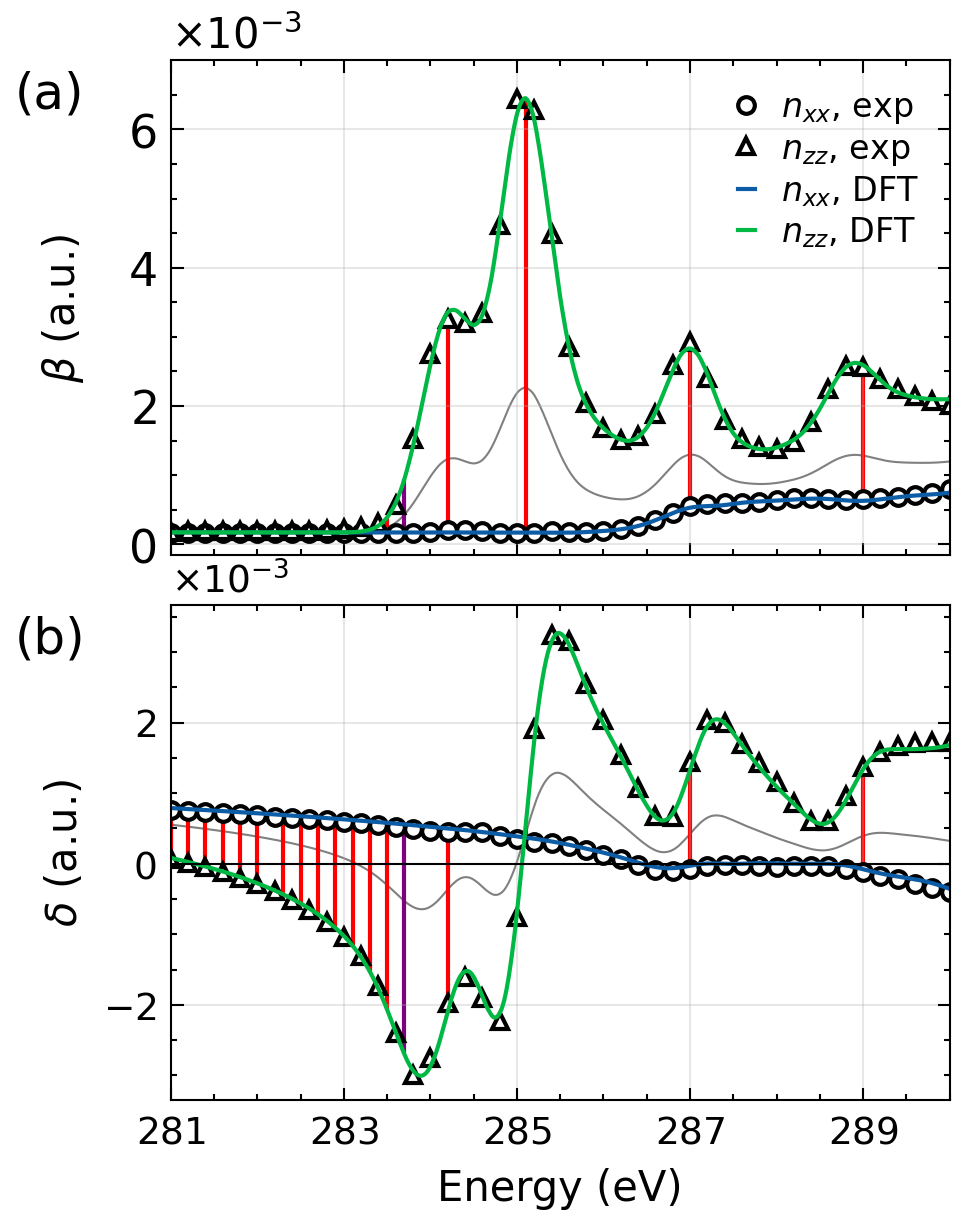

In [4]:
ub = 290
lb = 281


dft = dft[(dft["energy"] >= lb) & (dft["energy"] <= ub)]
exp = exp[(exp["energy"] >= lb) & (exp["energy"] <= ub)]

fig_width = 3.35
fig_height = 4.5
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(fig_width, fig_height),
    height_ratios=[1, 1],
    gridspec_kw={"hspace": 0.1},
    sharex=True,
    dpi=300,
)

# Plot (a): beta components (Imaginary part, n_ixx and n_izz)
ax1.plot(
    exp["energy"],
    exp["n_ixx"],
    "o",
    label=r"$n_{xx}$, exp",
    markeredgecolor="black",
    markerfacecolor="white",
    linestyle="none",
    markersize=4,
    markeredgewidth=1,
    markevery=10,
)
ax1.plot(
    exp["energy"],
    exp["n_izz"],
    "^",
    label=r"$n_{zz}$, exp",
    markeredgecolor="black",
    markerfacecolor="white",
    linestyle="none",
    markersize=4,
    markeredgewidth=1,
    markevery=10
)
ax1.plot(
    dft["energy"],
    dft["n_ixx"],
    "-",
    color="C0",
    linewidth=1,
    label=r"$n_{xx}$, DFT"
)
ax1.plot(
    dft["energy"],
    dft["n_izz"],
    "-",
    color="C1",
    linewidth=1,
    label=r"$n_{zz}$, DFT"
)
ax1.plot(
    dft["energy"],
    2*dft["n_ixx"]/3 + dft["n_izz"]/3,
    "-",
    color="grey",
    linewidth=.5,
    zorder=-10,
)

# Place (a) label in line with the y-axis label
ax1.set_ylabel(r"$\beta$ (a.u.)")
ax1.set_xlim(lb, ub)
ax1.yaxis.offsetText.set_fontsize(10)
ax1.tick_params(axis='both', which='major', labelsize=11)
ax1.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
ax1.legend(
    loc="upper right",
    frameon=False,
    labelspacing=0.2,
    ncols=1,
    handlelength=.5
)

# Plot (b): delta components (Real part, n_xx and n_zz)
ax2.plot(
    exp["energy"],
    exp["n_xx"],
    "o",
    label=None,
    markeredgecolor="black",
    markerfacecolor="white",
    linestyle="none",
    markersize=4,
    markeredgewidth=1,
    markevery=10
)
ax2.plot(
    exp["energy"],
    exp["n_zz"],
    "^",
    label=None,
    markeredgecolor="black",
    markerfacecolor="white",
    linestyle="none",
    markersize=4,
    markeredgewidth=1,
    markevery=10
)
ax2.plot(
    dft["energy"],
    dft["n_xx"],
    "-",
    color="C0",
    linewidth=1,
    label=None
)
ax2.plot(
    dft["energy"],
    dft["n_zz"],
    "-",
    color="C1",
    linewidth=1,
    label=None
)
ax2.plot(
    dft["energy"],
    2*dft["n_xx"]/3 + dft["n_zz"]/3,
    "-",
    color="grey",
    linewidth=.5,
    zorder=-10,
)
# Draw 0 as it is important
ax2.axhline(
    0,
    color = plt.rcParams["axes.edgecolor"],
    lw = plt.rcParams["axes.linewidth"],
)
# scientific notation for y axis
ax2.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))
# set x-labels to run 283, 285, 287, 289, 291, 293, 295
ax2.set_xticks([281, 283, 285, 287, 289])
ax2.set_xlabel(r"Energy (eV)")
# Place (b) label in line with the y-axis label below
ax2.set_ylabel(r"$\delta$ (a.u.)")

ax1.minorticks_on()
ax2.minorticks_on()
ax1.text(
    -0.20, 0.98, "(a)", transform=ax1.transAxes,
    fontsize=12, va="top", ha="left"
)

ax2.text(
    -0.20, 0.98, "(b)", transform=ax2.transAxes,
    fontsize=12, va="top", ha="left"
)

def at(df, val, col):
    """
    Interpolates the values along column `col` of dataframe `df` using
    Akima1DInterpolator (makima),
    and returns the interpolated value at position `val`.
    """
    x = df[col]
    y = df.drop(columns=[col])
    interp = Akima1DInterpolator(x, y.values, axis=0)
    return interp(val)

for en in pxr:
    val = at(dft, en, "energy")
    avg = val[-2]*2/3 + val[-1]*1/3
    avgr = val[0]*2/3 + val[1]*1/3
    color = "r" if en != 283.7 else "purple"
    # ax1.plot(en, avg, marker="|", color = color) if en >= 283.7 else None
    # ax2.plot(en, avgr, marker="|", color = color)
    ax1.vlines(
        en,
        val[-2],
        val[-1],
        color=color,
        zorder=-10,
        # lw = .5,
    )
    ax2.vlines(
        en,
        val[0],
        val[1],
        color=color,
        zorder=-10,
        # lw = .5,
    )
# shade between the 281 -> 283.5 eV

# ax2.fill_between(
#     dft["energy"], dft["n_xx"], dft["n_zz"],
#     where = (dft["energy"]<=283.5),
#     hatch="/////////",
#     edgecolor="orange",
#     facecolor="none",
#     hatch_linewidth=.5,
#     lw=.5,
#     zorder=-20,
# )

fig.align_labels()
fig.tight_layout()
# save the figure
fig.savefig("fig1_dft_tensor_component_comparison.png", dpi=600, bbox_inches="tight",
    transparent=True,
)

delta n_xx zero crossing(s): 286.44, 287.16, 287.40, 287.60, 288.61 eV
delta n_zz zero crossing(s): 281.28, 285.06 eV
isotropic delta crossing(s): 283.14, 284.99 eV
--- manuscript numbers ---
beta : max eps = 4.35% at 290.00 eV | mean = 1.08% | at 283.7 eV = 0.21%
delta: max eps = 7.30% at 284.08 eV | mean = 3.56% | at 283.7 eV = 4.30%
total: max eps = 5.32% at 284.08 eV | mean over 281-290 eV = 2.71%
  n_xx: +5.79% at 283.7 eV, max |dev| = 8.80% at 284.08 eV
  n_zz: +1.86% at 283.7 eV, max |dev| = 5.52% at 284.10 eV
  n_ixx: +0.26% at 283.7 eV, max |dev| = 6.02% at 290.00 eV
  n_izz: -0.15% at 283.7 eV, max |dev| = 3.43% at 285.06 eV
--- caption sentence (LaTeX) ---
The DFT-derived tensor reproduces the experimental optical constants to within 2.7\% on average over 281--290\,eV, with maximum deviations of 4.3\% in $\beta$ at 290.0\,eV and 7.3\% in $\delta$ at 284.1\,eV.


/var/folders/r8/f7plnn3j0pl84gbjlks1md7h0000gn/T/ipykernel_61370/1806875559.py:479: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


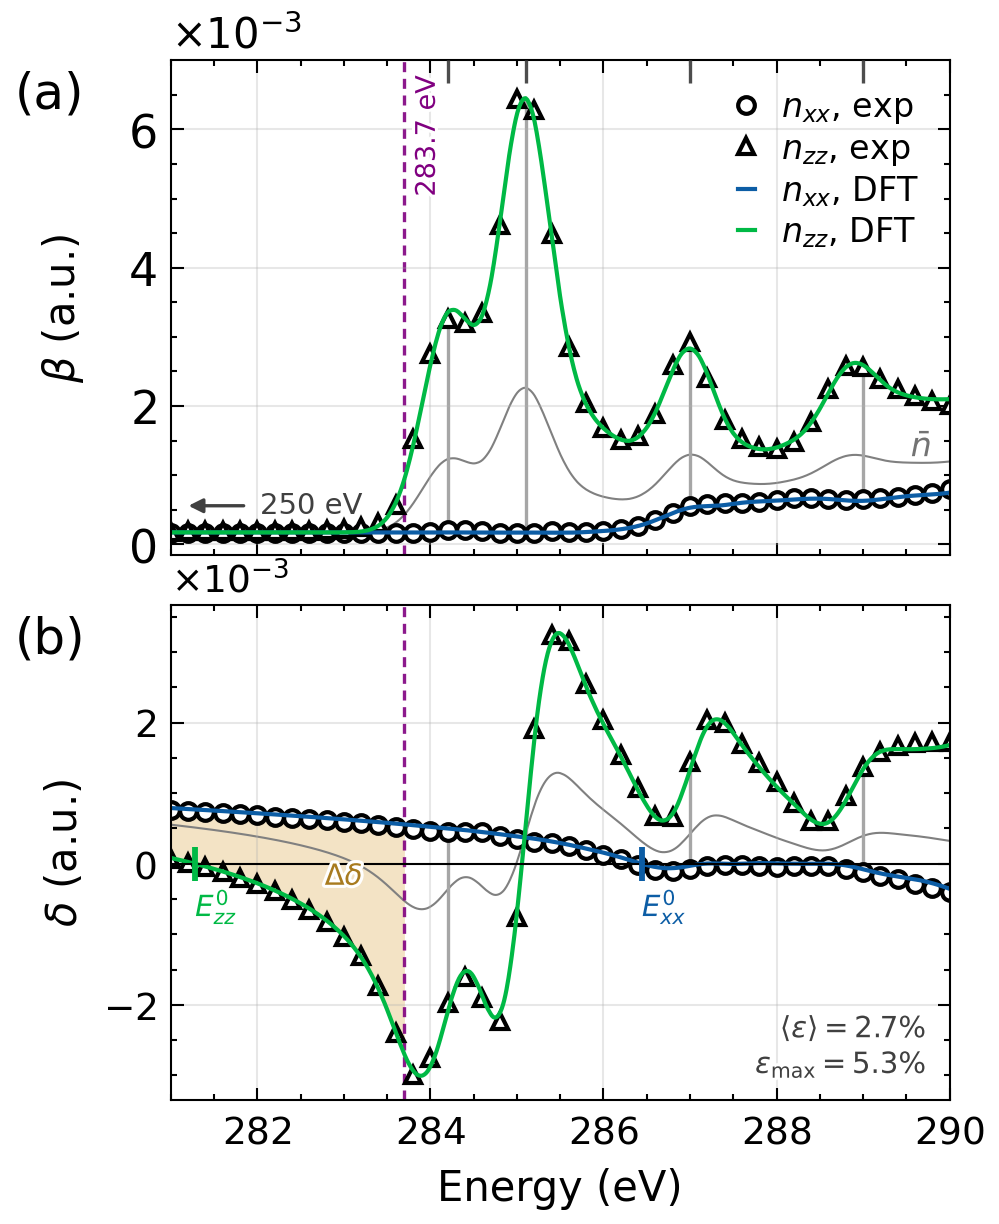

In [24]:
"""
Figure 1: ZnPc index-of-refraction tensor across the carbon K-edge.

Panels
  (a)  beta components (n_ixx, n_izz), exp markers vs DFT curves
  (b)  delta components (n_xx, n_zz), with component-resolved zero
       crossings and the isotropic average

Annotation channels (one encoding each)
  dashed purple vline   283.7 eV long-q probe, spanning both panels;
                        the cross fill terminates against it
  tick comb             sparse PXR probe energies (> 283.7 eV) on the
                        top spine of (a)
  grey bars             local n_xx -> n_zz span, only at the sparse
                        probe energies above 283.7 eV
  gold fill             delta_xx -> delta_zz splitting through the
                        fine-grid pre-edge, panel (b)
  "|" ticks             first delta zero crossing per component, on the
                        delta = 0 line, color-matched + labeled
  arrow                 off-axis 250 eV non-resonant deep probe

Prerequisites: dft, exp (read_ooc frames), pxr energy list,
Akima1DInterpolator imported.
"""

import matplotlib.patheffects as pe
import matplotlib.transforms as mtransforms

STROKE = [pe.Stroke(linewidth=1.5, foreground="white"), pe.Normal()]

ub = 290
lb = 281

FINE_LO, FINE_HI = 281.0, 283.5   # 0.2 eV sampling window (reference only)
E_HIQ = 283.7                     # long-q probe energy; cross-fill upper edge

# ── Visual-variant flags ─────────────────────────────────────────────────────
SHOW_SPAN_BARS = True    # grey n_xx -> n_zz bars at sparse probe energies
ANNOTATE_EPS = True      # compact eps stats block in panel (b)

PURPLE = "purple"

# Pre-edge cross fill, panel (b). Soft gold separates cleanly from C0/C1.
FILL_COLOR = "#D9A441"
FILL_ALPHA = 0.30
FILL_LBL = (283.0, 0.45)          # (data x, axes-fraction y); nudge
FILL_LBL_COLOR = "#A87B1F"

# Direct curve-label positions (axes fraction); nudge per final render.
CURVE_LBL = {
    "iso":  (0.95, 0.2, "0.45"),
}

# Crossing-label offsets in display points from each "|" tick; nudge.
CROSS_LBL_OFF = {
    "n_xx": (0, -15),
    "n_zz": (0, -15),
}

# Long-q label position, panel (a): (axes-fraction y, points x-offset); nudge.
HIQ_LBL_Y = 0.97
HIQ_LBL_DX = 2.5

# Eps stats block anchor (axes fraction, panel b); nudge per final render.
EPS_LBL = (0.97, 0.04)

dft = dft[(dft["energy"] >= lb) & (dft["energy"] <= ub)]
exp = exp[(exp["energy"] >= lb) & (exp["energy"] <= ub)]


def density_scale(component, density):
    return component * density

def rotate_tensor(xx, zz, gamma):
    xx_r = (xx * (1+np.cos(gamma)**2) + zz * np.sin(gamma)**2) / 2
    zz_r = xx * np.sin(gamma)**2 + zz * np.cos(gamma)**2
    return xx_r, zz_r

def tensor_deviation(dft_df, exp_df, lo, hi,
                     components=("n_xx", "n_zz", "n_ixx", "n_izz")):
    """
    Normalized DFT-vs-exp tensor deviation on a common energy grid.

    Each component difference is scaled by the maximum magnitude of the
    experimental component over the window (delta crosses zero, so a
    pointwise relative error is ill-defined there). epsilon(E) is the RMS
    over the four scaled components, in percent. Returns the grid, the
    combined epsilon, and the per-component signed deviations.
    """
    grid = np.linspace(lo, hi, 1500)
    eps_sq = np.zeros_like(grid)
    per = {}
    for c in components:
        d = np.interp(grid, dft_df["energy"], dft_df[c])
        x = np.interp(grid, exp_df["energy"], exp_df[c])
        scale = float(np.max(np.abs(x)))
        per[c] = 100.0 * (d - x) / scale
        eps_sq += per[c] ** 2
    eps = np.sqrt(eps_sq / len(components))
    return grid, eps, per


def zero_crossings(e, y):
    """Linear-interpolated zero crossings of y(e); returns a list of energies."""
    e = np.asarray(e, dtype=float)
    y = np.asarray(y, dtype=float)
    idx = np.where(np.diff(np.sign(y)) != 0)[0]
    return [
        e[j] - y[j] * (e[j + 1] - e[j]) / (y[j + 1] - y[j]) for j in idx
    ]


fig_width = 3.35
fig_height = 4.5
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(fig_width, fig_height),
    height_ratios=[1, 1],
    gridspec_kw={"hspace": 0.1},
    sharex=True,
    dpi=300,
)

# ── Panel (a): beta components ───────────────────────────────────────────────

ax1.plot(
    exp["energy"],
    exp["n_ixx"],
    "o",
    label=r"$n_{xx}$, exp",
    markeredgecolor="black",
    markerfacecolor="white",
    linestyle="none",
    markersize=4,
    markeredgewidth=1,
    markevery=10,
)
ax1.plot(
    exp["energy"],
    exp["n_izz"],
    "^",
    label=r"$n_{zz}$, exp",
    markeredgecolor="black",
    markerfacecolor="white",
    linestyle="none",
    markersize=4,
    markeredgewidth=1,
    markevery=10,
)
ax1.plot(
    dft["energy"],
    dft["n_ixx"],
    "-",
    color="C0",
    linewidth=1,
    label=r"$n_{xx}$, DFT",
)
ax1.plot(
    dft["energy"],
    dft["n_izz"],
    "-",
    color="C1",
    linewidth=1,
    label=r"$n_{zz}$, DFT",
)
ax1_ylim = ax1.get_ylim()
# Define a tighter gradation: mostly close to 1, some further out
# density_gradation = np.array([1.0, 1.01, 1.03, 1.08, 1.15, 1.2, 1.3])
# center = 1.0
# for density in density_gradation:
#     # Alpha gets lighter the further from 1.0
#     alpha = max(0.05, 0.55 - abs(density - center)*2)
#     ixx_d = density_scale(dft["n_ixx"], density)
#     izz_d = density_scale(dft["n_izz"], density)
#     ax1.plot(
#         dft["energy"],
#         ixx_d,
#         "-",
#         color="C0",
#         linewidth=0.6,
#         # zorder=-10,
#         alpha=alpha,
#     )
#     ax1.plot(
#         dft["energy"],
#         izz_d,
#         "-",
#         color="C1",
#         linewidth=0.6,
#         # zorder=-10,
#         alpha=alpha,
#     )
# Reset the y-limits to the original values
ax1.set_ylim(ax1_ylim)

ax1.plot(
    dft["energy"],
    2 * dft["n_ixx"] / 3 + dft["n_izz"] / 3,
    "-",
    color="grey",
    linewidth=0.5,
    zorder=-10,
)

ax1.set_ylabel(r"$\beta$ (a.u.)")
ax1.set_xlim(lb, ub)
ax1.yaxis.offsetText.set_fontsize(10)
ax1.tick_params(axis="both", which="major", labelsize=11)
ax1.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
ax1.legend(
    loc="upper right",
    frameon=False,
    labelspacing=0.2,
    ncols=1,
    handlelength=0.5,
)

# Direct curve labels (component color carries to panel b).
for key, (xf, yf, col) in CURVE_LBL.items():
    txt = {"n_zz": r"$n_{zz}$", "n_xx": r"$n_{xx}$", "iso": r"$\bar{n}$"}[key]
    ax1.text(
        xf, yf, txt, transform=ax1.transAxes,
        color=col, fontsize=8,
        ha="right" if key == "n_zz" else "left",
        path_effects=STROKE,
    )

# Off-axis 250 eV non-resonant deep probe.
ax1.annotate(
    r"250 eV", xy=(0.012, 0.1), xytext=(0.115, 0.1),
    xycoords="axes fraction", textcoords="axes fraction",
    ha="left", va="center", fontsize=7, color="0.25",
    arrowprops=dict(arrowstyle="-|>", color="0.25", lw=0.8),
)

# ── Panel (b): delta components ──────────────────────────────────────────────

ax2.plot(
    exp["energy"],
    exp["n_xx"],
    "o",
    label=None,
    markeredgecolor="black",
    markerfacecolor="white",
    linestyle="none",
    markersize=4,
    markeredgewidth=1,
    markevery=10,
)
ax2.plot(
    exp["energy"],
    exp["n_zz"],
    "^",
    label=None,
    markeredgecolor="black",
    markerfacecolor="white",
    linestyle="none",
    markersize=4,
    markeredgewidth=1,
    markevery=10,
)
ax2.plot(dft["energy"], dft["n_xx"], "-", color="C0", linewidth=1, label=None)
ax2.plot(dft["energy"], dft["n_zz"], "-", color="C1", linewidth=1, label=None)

iso_delta = 2 * dft["n_xx"] / 3 + dft["n_zz"] / 3
ax2.plot(
    dft["energy"], iso_delta, "-",
    color="grey", linewidth=0.5, zorder=-10,
)
ax2.axhline(
    0,
    color=plt.rcParams["axes.edgecolor"],
    lw=plt.rcParams["axes.linewidth"],
)
ax2.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))
ax2.set_ylabel(r"$\delta$ (a.u.)")
ax2.set_xlabel("Energy (eV)")

# orientation_gradation = np.deg2rad([0, .5, 2, 5, 10, 20, 30, 40,50])
# for orientation in orientation_gradation:
#     xx_r, zz_r = rotate_tensor(dft["n_xx"], dft["n_zz"], orientation)
#     alpha = max(0.05, 0.55 - abs(orientation - center)*2)
#     ax2.plot(
#         dft["energy"],
#         xx_r,
#         "-",
#         color="C0",
#         linewidth=.5,
#         # zorder=-10,
#         alpha=alpha,
#     )
#     ax2.plot(
#         dft["energy"],
#         zz_r,
#         "-",
#         color="C1",
#         linewidth=.5,
#         # zorder=-10,
#         alpha=alpha,
#     )

# ── Long-q probe: one encoding, both panels ──────────────────────────────────
# Dashed purple vline at 283.7 eV; the cross fill terminates against it.
# Replaces the purple comb tick and the purple span bars.

for ax in (ax1, ax2):
    ax.axvline(
        E_HIQ, color=PURPLE, lw=0.8, ls=(0, (3, 2)), alpha=0.9, zorder=-5,
    )
ax1.annotate(
    f"{E_HIQ} eV",
    xy=(E_HIQ, HIQ_LBL_Y),
    xycoords=mtransforms.blended_transform_factory(ax1.transData, ax1.transAxes),
    xytext=(HIQ_LBL_DX, 0), textcoords="offset points",
    rotation=90, ha="left", va="top",
    fontsize=6.5, color=PURPLE, path_effects=STROKE, zorder=6,
)

# ── Delta zero crossings, component resolved ─────────────────────────────────
# First crossing only, one per component. Vertical "|" ticks through the
# delta = 0 line; no other element in the figure uses this glyph, so they
# cannot be confused with exp data markers. Labels nudge via CROSS_LBL_OFF
# (display points). All crossings are still printed for the text.

cross = {}
for key, ydata, color, lbl in (
    ("n_xx", dft["n_xx"], "C0", r"$E^{0}_{xx}$"),
    ("n_zz", dft["n_zz"], "C1", r"$E^{0}_{zz}$"),
):
    cs = zero_crossings(dft["energy"], ydata)
    cross[key] = cs
    if cs:
        ax2.plot(
            cs[0], 0, marker="|", ms=8, mec=color, mew=1.4,
            linestyle="none", zorder=6,
        )
        ax2.annotate(
            lbl, xy=(cs[0], 0),
            xytext=CROSS_LBL_OFF[key], textcoords="offset points",
            color=color, fontsize=7, ha="left", va="bottom",
            path_effects=STROKE, zorder=6,
        )
        print(
            f"delta {key} zero crossing(s): "
            + ", ".join(f"{c:.2f}" for c in cs) + " eV"
        )
print(
    "isotropic delta crossing(s): "
    + ", ".join(f"{c:.2f}" for c in zero_crossings(dft["energy"], iso_delta))
    + " eV"
)

# Pre-edge cross fill: delta_xx -> delta_zz splitting through the fine-grid
# window, terminating at the long-q line. Carries both the fine-sampling
# message and the tensor-splitting magnitude; labeled directly.
_e = dft["energy"].to_numpy()
_m = _e <= E_HIQ
ax2.fill_between(
    _e[_m], dft["n_xx"].to_numpy()[_m], dft["n_zz"].to_numpy()[_m],
    color=FILL_COLOR, alpha=FILL_ALPHA, lw=0, zorder=-15,
)
ax2.text(
    FILL_LBL[0], FILL_LBL[1], r"$\Delta\delta$",
    transform=mtransforms.blended_transform_factory(ax2.transData, ax2.transAxes),
    color=FILL_LBL_COLOR, fontsize=7, ha="center", va="center",
    path_effects=STROKE, zorder=4,
)

# ── Probe-energy indicators ──────────────────────────────────────────────────

def at(df, val, col):
    """
    Interpolates the values along column `col` of dataframe `df` using
    Akima1DInterpolator (makima),
    and returns the interpolated value at position `val`.
    """
    x = df[col]
    y = df.drop(columns=[col])
    interp = Akima1DInterpolator(x, y.values, axis=0)
    return interp(val)


# Tick comb hanging from the top spine of (a): sparse probe energies only.
# The pre-edge fine grid is carried by the fill, the long-q energy by the
# dashed vline, so neither appears in the comb.
comb_tr = mtransforms.blended_transform_factory(ax1.transData, ax1.transAxes)
for en in pxr:
    if en <= E_HIQ or en > ub:
        continue
    ax1.plot(
        [en, en], [1.0, 0.955],
        transform=comb_tr,
        color="0.3",
        lw=0.8,
        solid_capstyle="butt",
        clip_on=False,
        zorder=5,
    )

# Span bars: local n_xx -> n_zz tensor splitting, only at the sparse probe
# energies above the long-q line. Below it the fill carries the span, so
# bars there would just fence the shading.
if SHOW_SPAN_BARS:
    for en in pxr:
        if en <= E_HIQ or en > ub:
            continue
        val = at(dft, en, "energy")
        ax1.vlines(en, val[-2], val[-1], color="0.65", lw=0.8, zorder=-10)
        ax2.vlines(en, val[0], val[1], color="0.65", lw=0.8, zorder=-10)

# ── Eps stats block, panel (b) ───────────────────────────────────────────────
# Compact presentation of the total and peak percent error; no pointer.

grid, eps, per = tensor_deviation(dft, exp, lb, ub)
_imax = int(np.argmax(eps))
if ANNOTATE_EPS:
    ax2.text(
        *EPS_LBL,
        rf"$\langle\varepsilon\rangle = {eps.mean():.1f}\%$"
        "\n"
        rf"$\varepsilon_{{\max}} = {eps[_imax]:.1f}\%$",
        transform=ax2.transAxes,
        fontsize=7, color="0.25", ha="right", va="bottom",
        linespacing=1.3, path_effects=STROKE,
    )

# ── Panel labels ─────────────────────────────────────────────────────────────

ax1.minorticks_on()
ax2.minorticks_on()
ax1.text(-0.20, 0.98, "(a)", transform=ax1.transAxes,
         fontsize=12, va="top", ha="left")
ax2.text(-0.20, 0.98, "(b)", transform=ax2.transAxes,
         fontsize=12, va="top", ha="left")

# ── Manuscript numbers ───────────────────────────────────────────────────────


def group_dev(comps):
    """RMS deviation over a component subset; returns (curve, argmax index)."""
    d = np.sqrt(sum(per[c] ** 2 for c in comps) / len(comps))
    return d, int(np.argmax(d))


dev_b, ib = group_dev(("n_ixx", "n_izz"))
dev_d, idx_d = group_dev(("n_xx", "n_zz"))
_i37 = int(np.argmin(np.abs(grid - E_HIQ)))

print("--- manuscript numbers ---")
print(
    f"beta : max eps = {dev_b[ib]:.2f}% at {grid[ib]:.2f} eV | "
    f"mean = {dev_b.mean():.2f}% | at 283.7 eV = {dev_b[_i37]:.2f}%"
)
print(
    f"delta: max eps = {dev_d[idx_d]:.2f}% at {grid[idx_d]:.2f} eV | "
    f"mean = {dev_d.mean():.2f}% | at 283.7 eV = {dev_d[_i37]:.2f}%"
)
print(
    f"total: max eps = {eps[_imax]:.2f}% at {grid[_imax]:.2f} eV | "
    f"mean over {lb}-{ub} eV = {eps.mean():.2f}%"
)
for _c, _v in per.items():
    print(
        f"  {_c}: {_v[_i37]:+.2f}% at 283.7 eV, "
        f"max |dev| = {np.max(np.abs(_v)):.2f}% "
        f"at {grid[int(np.argmax(np.abs(_v)))]:.2f} eV"
    )

print("--- caption sentence (LaTeX) ---")
print(
    f"The DFT-derived tensor reproduces the experimental optical constants "
    f"to within {eps.mean():.1f}\\% on average over {lb}--{ub}\\,eV, with "
    f"maximum deviations of {dev_b[ib]:.1f}\\% in $\\beta$ at "
    f"{grid[ib]:.1f}\\,eV and {dev_d[idx_d]:.1f}\\% in $\\delta$ at "
    f"{grid[idx_d]:.1f}\\,eV."
)

fig.align_labels()
fig.tight_layout()
fig.savefig(
    "fig1_dft_tensor_component_comparison.png", dpi=600, bbox_inches="tight",
    transparent=True,
)
fig.savefig(
    "fig1_dft_tensor_component_comparison.pdf", dpi=600, bbox_inches="tight",
    transparent=True,
)

/var/folders/r8/f7plnn3j0pl84gbjlks1md7h0000gn/T/ipykernel_61370/646768889.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


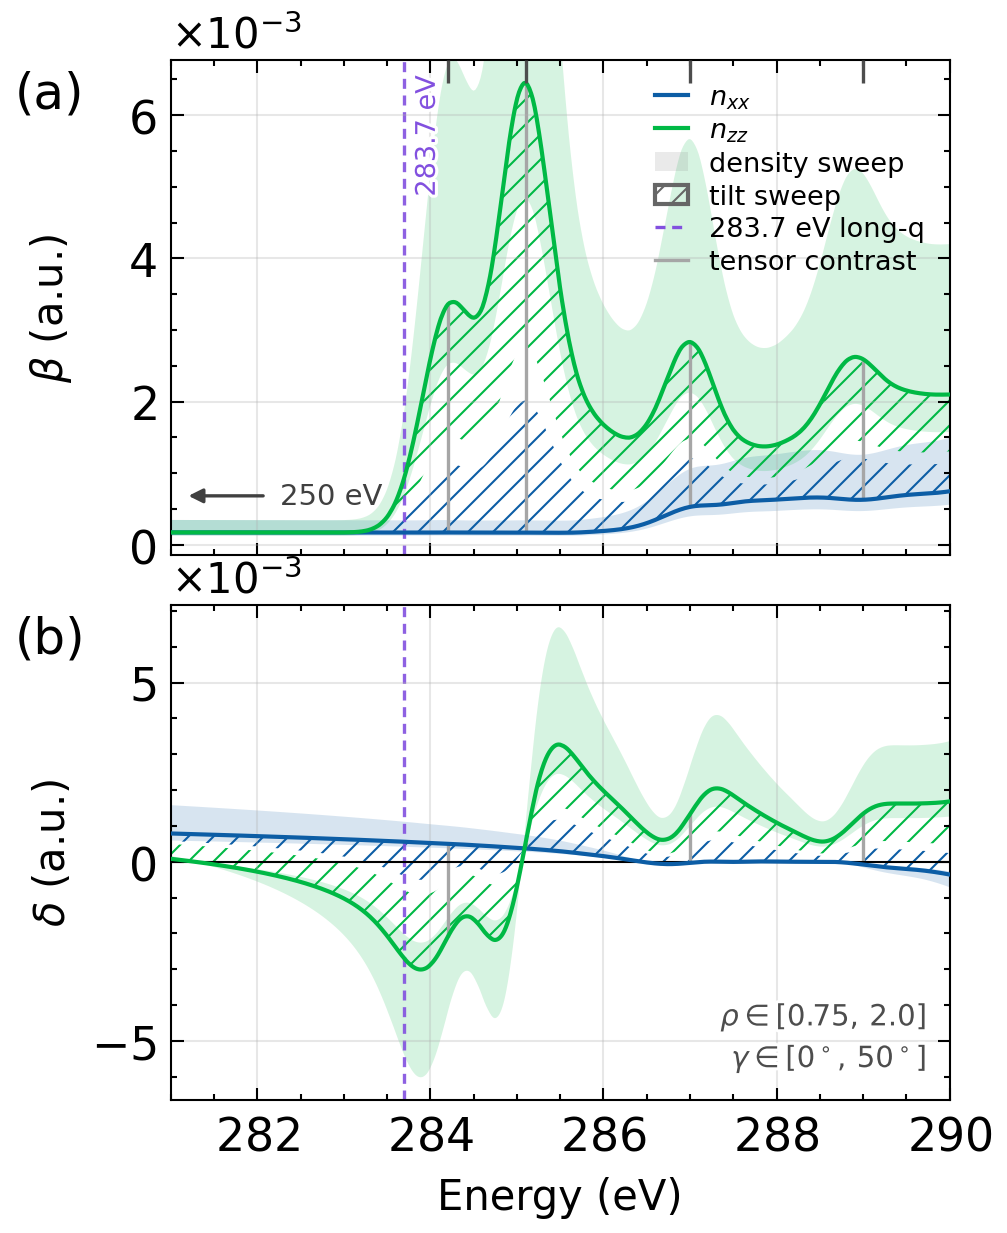

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.rcParams["hatch.linewidth"] = 0.5
STROKE = [pe.Stroke(linewidth=1.5, foreground="white"), pe.Normal()]

lb, ub = 281, 290
E_HIQ = 283.7
PURPLE = "#8250DF"

# ── Dial ranges ──────────────────────────────────────────────────────────────
rho = np.array([0.75, 0.9, 1.0, 1.25, 1.5, 2.0])        # density factor
gam = np.deg2rad(np.array([0, 10, 20, 30, 40, 50]))     # orientation factor

def density_scale(component, density):
    return component * density

def rotate_tensor(xx, zz, gamma):
    xx_r = (xx * (1 + np.cos(gamma) ** 2) + zz * np.sin(gamma) ** 2) / 2
    zz_r = xx * np.sin(gamma) ** 2 + zz * np.cos(gamma) ** 2
    return xx_r, zz_r

def density_band(comp):
    """Min/max envelope of a component swept over the density dial."""
    stack = np.outer(rho, comp)
    return stack.min(axis=0), stack.max(axis=0)

def orient_band(xx, zz):
    """Min/max envelopes of both components swept over the tilt dial."""
    xr = np.array([rotate_tensor(xx, zz, g)[0] for g in gam])
    zr = np.array([rotate_tensor(xx, zz, g)[1] for g in gam])
    return (xr.min(0), xr.max(0)), (zr.min(0), zr.max(0))

def interp_at(e, y, val):
    return np.interp(val, e, y)

# ── Data ─────────────────────────────────────────────────────────────────────
d = dft[(dft["energy"] >= lb) & (dft["energy"] <= ub)]
e = d["energy"].to_numpy()
b_xx, b_zz = d["n_ixx"].to_numpy(), d["n_izz"].to_numpy()   # beta traces
d_xx, d_zz = d["n_xx"].to_numpy(),  d["n_zz"].to_numpy()    # delta traces

# ── Panel drawer ─────────────────────────────────────────────────────────────
def draw_dials(ax, xx, zz, clip_to_nominal=True):
    l0, = ax.plot(e, xx, "-", color="C0", lw=1.0, zorder=3)
    l1, = ax.plot(e, zz, "-", color="C1", lw=1.0, zorder=3)
    yl = ax.get_ylim()
    for comp, c in ((xx, "C0"), (zz, "C1")):        # density, solid tint
        lo, hi = density_band(comp)
        ax.fill_between(e, lo, hi, facecolor=c, alpha=0.16, lw=0, zorder=-12)
    (xlo, xhi), (zlo, zhi) = orient_band(xx, zz)    # orientation, hatch
    ax.fill_between(e, xlo, xhi, facecolor="none", edgecolor="C0",
                    hatch="////", lw=0, zorder=-11)
    ax.fill_between(e, zlo, zhi, facecolor="none", edgecolor="C1",
                    hatch="////", lw=0, zorder=-11)
    if clip_to_nominal:
        ax.set_ylim(yl)
    return l0, l1

# ── Figure ───────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(3.35, 4.5), sharex=True, dpi=300,
    gridspec_kw={"hspace": 0.1},
)

draw_dials(ax1, b_xx, b_zz, clip_to_nominal=True)   # beta
draw_dials(ax2, d_xx, d_zz, clip_to_nominal=False)  # delta
ax2.axhline(0, color=plt.rcParams["axes.edgecolor"],
            lw=plt.rcParams["axes.linewidth"])

# ── Probe energies (one channel, both panels) ────────────────────────────────
for ax in (ax1, ax2):
    ax.axvline(E_HIQ, color=PURPLE, lw=0.8, ls=(0, (3, 2)), alpha=0.9, zorder=-5)

comb_tr = mtransforms.blended_transform_factory(ax1.transData, ax1.transAxes)
for en in pxr:
    if E_HIQ < en <= ub:
        ax1.plot([en, en], [1.0, 0.955], transform=comb_tr, color="0.3",
                 lw=0.8, solid_capstyle="butt", clip_on=False, zorder=5)
        ax1.vlines(en, interp_at(e, b_xx, en), interp_at(e, b_zz, en),
                   color="0.65", lw=0.8, zorder=-8)
        ax2.vlines(en, interp_at(e, d_xx, en), interp_at(e, d_zz, en),
                   color="0.65", lw=0.8, zorder=-8)

ax1.annotate(f"{E_HIQ} eV",
             xy=(E_HIQ, 0.97), xytext=(2.5, 0), textcoords="offset points",
             xycoords=mtransforms.blended_transform_factory(ax1.transData, ax1.transAxes),
             rotation=90, ha="left", va="top", fontsize=6.5,
             color=PURPLE, path_effects=STROKE, zorder=6)

ax1.annotate("250 eV", xy=(0.012, 0.12), xytext=(0.14, 0.12),
             xycoords="axes fraction", textcoords="axes fraction",
             ha="left", va="center", fontsize=7, color="0.25",
             arrowprops=dict(arrowstyle="-|>", color="0.25", lw=0.8))

# ── Dial-range key ───────────────────────────────────────────────────────────
ax2.text(0.97, 0.05,
         r"$\rho \in [0.75,\,2.0]$" "\n" r"$\gamma \in [0^\circ,\,50^\circ]$",
         transform=ax2.transAxes, fontsize=7, ha="right", va="bottom",
         color="0.3", linespacing=1.4, path_effects=STROKE)

# ── Cosmetics ────────────────────────────────────────────────────────────────
ax1.set_ylabel(r"$\beta$ (a.u.)")
ax2.set_ylabel(r"$\delta$ (a.u.)")
ax2.set_xlabel("Energy (eV)")
ax1.set_xlim(lb, ub)
for ax in (ax1, ax2):
    ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
    ax.yaxis.offsetText.set_fontsize(10)
    ax.tick_params(axis="both", which="major", labelsize=11)
    ax.minorticks_on()

handles = [
    Line2D([0], [0], color="C0", lw=1, label=r"$n_{xx}$"),
    Line2D([0], [0], color="C1", lw=1, label=r"$n_{zz}$"),
    Patch(facecolor="0.5", alpha=0.16, label="density sweep"),
    Patch(facecolor="none", edgecolor="0.4", hatch="////", label="tilt sweep"),
    Line2D([0], [0], color=PURPLE, lw=0.8, ls=(0, (3, 2)), label="283.7 eV long-q"),
    Line2D([0], [0], color="0.65", lw=0.8, label="tensor contrast"),
]
ax1.legend(handles=handles, loc="upper right", frameon=False,
           fontsize=6.5, labelspacing=0.25, handlelength=1.2)

ax1.text(-0.20, 0.98, "(a)", transform=ax1.transAxes, fontsize=12, va="top")
ax2.text(-0.20, 0.98, "(b)", transform=ax2.transAxes, fontsize=12, va="top")

fig.align_labels()
fig.tight_layout()
fig.savefig("fig1_dials_probe_energies.png", dpi=600,
            bbox_inches="tight", transparent=True)
fig.savefig("fig1_dials_probe_energies.pdf", dpi=600,
            bbox_inches="tight", transparent=True)

In [20]:
at(dft, en, "energy")

array([ 0.00055832, -0.00270131,  0.00017101,  0.00094636])

In [ ]:

# Load the already normalized NEXAFS data
raw = pd.read_csv("/home/hduva/projects/xrr_notebooks/fitting/normalized_dft_nexafs.csv")
exp = pd.read_csv("/home/hduva/projects/xrr_notebooks/fitting/normalized_nexafs.csv")


# Create a nice and pretty plot
def plot_dft(fig, ax, raw, dft):
    """Plot raw and DFT data."""
    sns.lineplot(
        data=raw,
        x="Energy",
        y="Normalized Intensity",
        hue="Angle",
        palette="viridis",
        linewidth=2.5,
        ax=ax,
        alpha=0.5,
    )
    sns.lineplot(
        data=dft,
        x="Energy",
        y="Normalized Intensity",
        hue="Angle",
        palette="viridis",
        linewidth=2.5,
        linestyle="--",
        ax=ax,
        legend=False,
    )

    # Customize the plot
    ax.set_xlabel("Energy (eV)", fontsize=14, fontweight="bold")
    ax.set_ylabel(r"$\beta (\theta)$", fontsize=14, fontweight="bold")
    ax.set_title(
        "Normalized Experimental NEXAFS Data", fontsize=16, fontweight="bold", pad=20
    )
    # Use scientific notation for y-axis
    ax.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))
    ax.set_xlim(283, 295)

    # Customize legend
    legend = ax.legend(
        title="Angle (degrees)",
        title_fontsize=12,
        fontsize=11,
        frameon=True,
        fancybox=False,
        shadow=False,
    )
    legend.get_frame().set_facecolor("white")
    legend.get_frame().set_alpha(0.9)

    # Add grid and styling
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.tick_params(direction="in", labelsize=11)


fig, ax = plt.subplots(figsize=(10, 6))
plot_dft(fig, ax, raw, dft)
# Adjust layout and save
plt.tight_layout()
# plt.savefig("nexafs_normalized.png", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'dft' is not defined

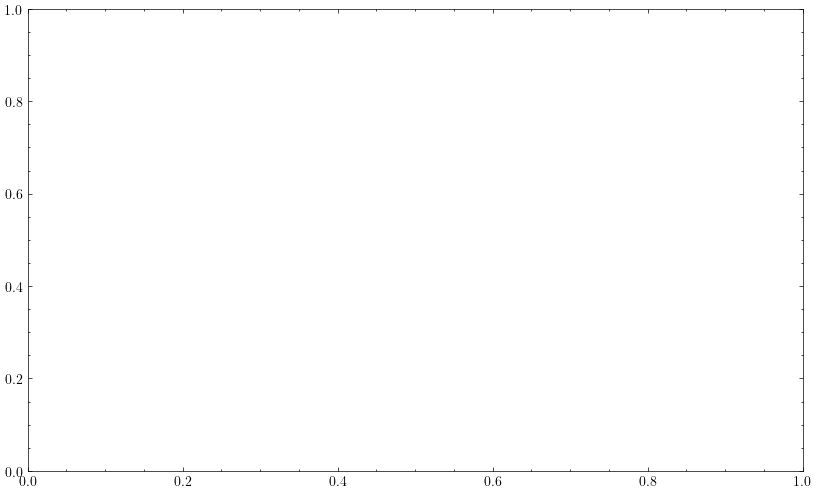

In [4]:
energy_vals = [
    250.0,
    275.0,
    280.0,
    281.0,
    281.2,
    281.4,
    281.6,
    281.8,
    282.0,
    282.3,
    282.5,
    282.7,
    282.9,
    283.1,
    283.3,
    283.5,
    283.7,
    284.2,
    285.1,
    287.0,
    289.0,
]
# Highlight the energies used in the fitting

fig, ax = plt.subplots(figsize=(10, 6))
plot_dft(fig, ax, raw, dft)
for ev in energy_vals:
    ax.axvline(ev, color="k", linestyle="--", alpha=0.3)
# Adjust layout and save
plt.tight_layout()
# plt.savefig("nexafs_normalized_with_energies.png", dpi=300, bbox_inches="tight")
plt.show()

(-0.001, 0.003)

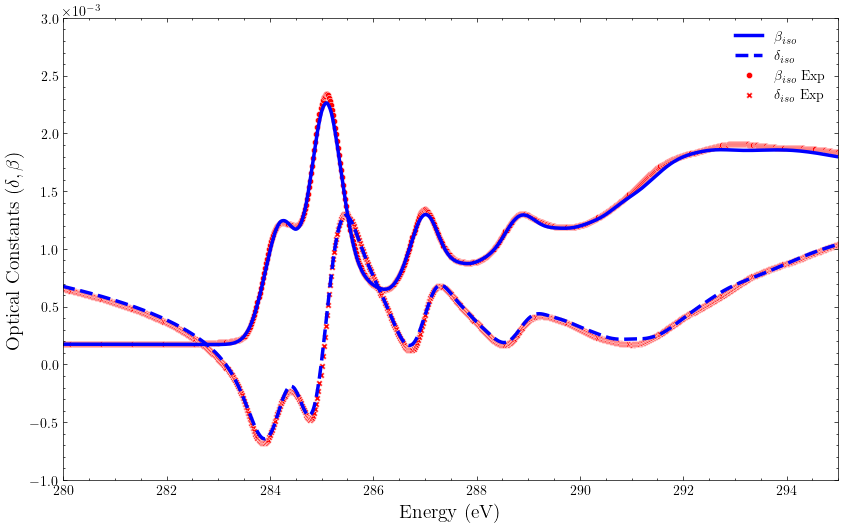

In [ ]:
import seaborn as sns

#  pull in the optical tensor components.

dft_optical_components = pd.read_csv("fitting/optical_constants.csv")
dft_optical_components["n_biso"] = (
    2 * dft_optical_components["n_ixx"] + dft_optical_components["n_izz"]
) / 3
dft_optical_components["n_diso"] = (
    2 * dft_optical_components["n_xx"] + dft_optical_components["n_zz"]
) / 3

exp_optical_components = pd.read_csv("fitting/optical_constants_exp.csv")
exp_optical_components["n_biso"] = (
    2 * exp_optical_components["n_ixx"] + exp_optical_components["n_izz"]
) / 3
exp_optical_components["n_diso"] = (
    2 * exp_optical_components["n_xx"] + exp_optical_components["n_zz"]
) / 3

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=dft_optical_components,
    x="energy",
    y="n_biso",
    label=r"$\beta_{iso}$",
    color="blue",
    linewidth=2.5,
    ax=ax,
)
sns.lineplot(
    data=dft_optical_components,
    x="energy",
    y="n_diso",
    label=r"$\delta_{iso}$",
    color="blue",
    linewidth=2.5,
    linestyle="--",
    ax=ax,
)
# Scatter plot with the experimental results
sns.scatterplot(
    data=exp_optical_components,
    x="energy",
    y="n_biso",
    label=r"$\beta_{iso}$ Exp",
    color="red",
    s=20,
    ax=ax,
)
sns.scatterplot(
    data=exp_optical_components,
    x="energy",
    y="n_diso",
    label=r"$\delta_{iso}$ Exp",
    color="red",
    s=20,
    marker="X",
    ax=ax,
)
ax.set_xlabel("Energy (eV)", fontsize=14, fontweight="bold")
ax.set_ylabel(r"Optical Constants $(\delta, \beta)$", fontsize=14, fontweight="bold")
ax.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))
ax.set_xlim(280, 295)
ax.set_ylim(-0.001, 0.003)

In [10]:
raw

,Energy,Intensity,Angle,Normalized Intensity
0,270.19992,5061.9155,20,0.000182
1,270.30038,5061.1460,20,0.000182
2,270.40048,5058.9800,20,0.000182
3,270.50085,5055.7681,20,0.000182
4,270.60025,5051.9160,20,0.000182
...,...,...,...,...
2990,329.60010,27137.0310,90,0.000824
2991,329.70013,27120.6640,90,0.000823
2992,329.79932,27107.0390,90,0.000823
2993,329.90030,27097.8500,90,0.000823


In [11]:
from kkcalc import kk

calc_exp = kk.kk_calculate_real(
    raw[raw["Angle"] == 55][["Energy", "Intensity"]].values,
    "C32H16N8Zn1",
    input_data_type="beta",
    load_options=None,
    merge_points=[
        raw[raw["Angle"] == 55]["Energy"].min(),
        raw[raw["Angle"] == 55]["Energy"].max(),
    ],
    add_background=False,
    curve_tolerance=0.01,
    curve_recursion=100,
)
stoichiometry = kk.data.ParseChemicalFormula("C32H16N8Zn1")
mass = kk.data.calculate_FormulaMass(stoichiometry)

exp_i = kk.data.convert_data(
    calc_exp[:, [0, 2]], "ASF", "refractive_index", Density=1, Formula_Mass=mass
)
exp_r = kk.data.convert_data(
    calc_exp[:, [0, 1]], "ASF", "refractive_index", Density=1, Formula_Mass=mass
)

In [12]:
energies = raw[raw["Angle"] == 55]["Energy"].values
# Create a DataFrame with the energies and the corresponding values
exp_optical_components = pd.DataFrame(
    {
        "Energy": energies,
        "n_biso": np.interp(energies, exp_i[:, 0], exp_i[:, 1]),
        "n_diso": np.interp(energies, exp_r[:, 0], exp_r[:, 1]),
    }
)

(-0.001, 0.003)

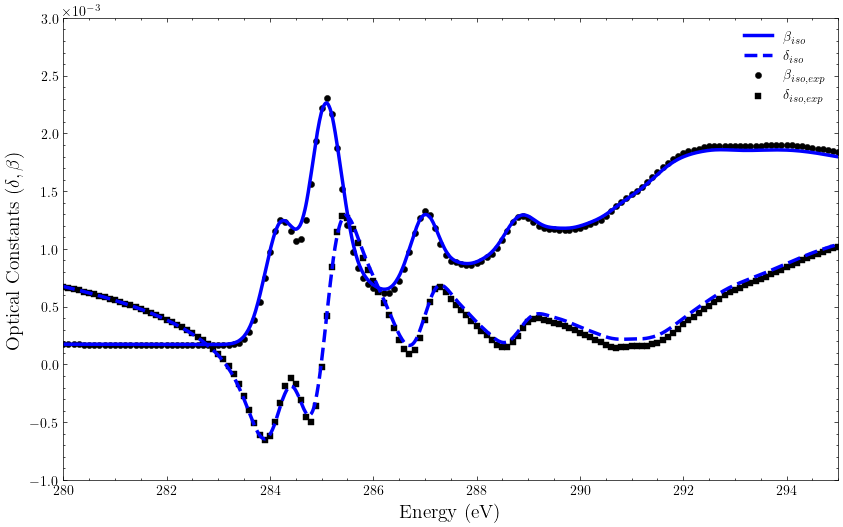

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=dft_optical_components,
    x="energy",
    y="n_biso",
    label=r"$\beta_{iso}$",
    color="blue",
    linewidth=2.5,
    ax=ax,
)
sns.lineplot(
    data=dft_optical_components,
    x="energy",
    y="n_diso",
    label=r"$\delta_{iso}$",
    color="blue",
    linewidth=2.5,
    linestyle="--",
    ax=ax,
)
sns.scatterplot(
    data=exp_optical_components,
    x="Energy",
    y="n_biso",
    label=r"$\beta_{iso, exp}$",
    color="k",
    s=20,
    edgecolor=None,
    linewidth=0.3,
    ax=ax,
)
sns.scatterplot(
    data=exp_optical_components,
    x="Energy",
    y="n_diso",
    label=r"$\delta_{iso, exp}$",
    color="k",
    s=20,
    marker="s",
    edgecolor=None,
    linewidth=0.3,
    ax=ax,
)
ax.set_xlabel("Energy (eV)", fontsize=14, fontweight="bold")
ax.set_ylabel(r"Optical Constants $(\delta, \beta)$", fontsize=14, fontweight="bold")
ax.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))
ax.set_xlim(280, 295)
ax.set_ylim(-0.001, 0.003)

(0.0, 0.03717718934999997)

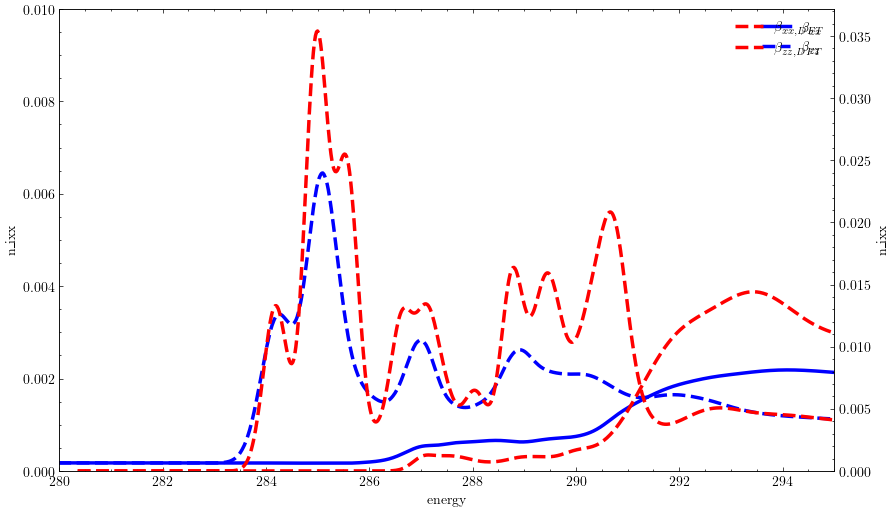

In [16]:
raw_dft = pd.read_csv("fitting/dft_raw_oocs.csv")
raw_dft.rename(
    columns={"eV_": "energy", "xxTotalf0": "n_ixx", "zzTotalf0": "n_izz"},
    inplace=True,
)
k_edge = (dft_optical_components["energy"] > 280) & (
    dft_optical_components["energy"] < 285
)
# find the energy corresponding to the max peak in this range
pi_peak = dft_optical_components[k_edge]["n_biso"].idxmax()
pi_peak_raw = raw_dft["n_izz"].idxmax()
shift = (
    dft_optical_components.loc[pi_peak, "energy"] - raw_dft.loc[pi_peak_raw, "energy"]
)
raw_dft["energy"] = raw_dft["energy"] + shift

fig, ax = plt.subplots(figsize=(10, 6))
twinx = ax.twinx()
sns.lineplot(
    data=dft_optical_components,
    x="energy",
    y="n_ixx",
    label=r"$\beta_{xx}$",
    color="blue",
    linewidth=2.5,
    ax=ax,
)
sns.lineplot(
    data=dft_optical_components,
    x="energy",
    y="n_izz",
    label=r"$\beta_{zz}$",
    color="blue",
    linewidth=2.5,
    linestyle="--",
    ax=ax,
)
sns.lineplot(
    data=raw_dft,
    x="energy",
    y="n_ixx",
    label=r"$\beta_{xx, DFT}$",
    color="red",
    linewidth=2.5,
    linestyle="--",
    ax=twinx,
)
sns.lineplot(
    data=raw_dft,
    x="energy",
    y="n_izz",
    label=r"$\beta_{zz, DFT}$",
    color="red",
    linewidth=2.5,
    linestyle="--",
    ax=twinx,
)

ax.set_xlim(280, 295)
ax.set_ylim(0, 0.01)
twinx.set_ylim(0, None)

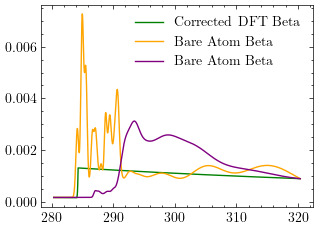

In [17]:
from periodictable.xsf import index_of_refraction

beta_bare_atom = -index_of_refraction(
    "C32H16N8Zn1", density=1.0, energy=raw_dft["energy"].values * 1e-3
).imag
# calculate the intensity scale and energy shift to alight the raw dft beta spectrum with
# the beta_bare_atom results in the pre and post edge regions
# corrected = raw_dft["n_biso"] * scale + shift


# compute scale and shift to exactly match first and last points
def scale_shift(raw_y0, raw_y1, target0, target1):
    if abs(raw_y1 - raw_y0) > 1e-20:
        scale = (target1 - target0) / (raw_y1 - raw_y0)
        shift = target0 - scale * raw_y0
    else:
        # fallback to mean-based estimate if raw endpoints are (almost) equal
        scale = target1 / raw_y1
        shift = target0 - scale * raw_y0
    return scale, shift


raw_y0z = raw_dft["n_izz"].iloc[0]
raw_y1z = raw_dft["n_izz"].iloc[-1]
raw_y0x = raw_dft["n_ixx"].iloc[0]
raw_y1x = raw_dft["n_ixx"].iloc[-1]
target0 = beta_bare_atom[0]
target1 = beta_bare_atom[-1]

scale_z, shift_z = scale_shift(raw_y0z, raw_y1z, target0, target1)
scale_x, shift_x = scale_shift(raw_y0x, raw_y1x, target0, target1)

corrected_z = raw_dft["n_izz"] * scale_z + shift_z
corrected_x = raw_dft["n_ixx"] * scale_x + shift_x

plt.plot(raw_dft["energy"], beta_bare_atom, label="Corrected DFT Beta", color="green")
plt.plot(
    raw_dft["energy"],
    corrected_z,
    label="Bare Atom Beta",
    color="orange",
)
plt.plot(
    raw_dft["energy"],
    corrected_x,
    label="Bare Atom Beta",
    color="purple",
)
plt.legend()

raw_dft["n_izz"] = corrected_z
raw_dft["n_ixx"] = corrected_x

In [18]:
#  kk calculate the n_diso
calc_raw_xx = kk.kk_calculate_real(
    raw_dft[["energy", "n_ixx"]].values,
    "C32H16N8Zn1",
    input_data_type="beta",
    load_options=None,
    merge_points=[
        raw_dft["energy"].min(),
        raw_dft["energy"].max(),
    ],
    add_background=False,
    curve_tolerance=0.01,
    curve_recursion=100,
)
calc_raw_zz = kk.kk_calculate_real(
    raw_dft[["energy", "n_izz"]].values,
    "C32H16N8Zn1",
    input_data_type="beta",
    load_options=None,
    merge_points=[
        raw_dft["energy"].min(),
        raw_dft["energy"].max(),
    ],
    add_background=False,
    curve_tolerance=0.01,
    curve_recursion=100,
)
stoichiometry = kk.data.ParseChemicalFormula("C32H16N8Zn1")
mass = kk.data.calculate_FormulaMass(stoichiometry)

raw_izz = kk.data.convert_data(
    calc_raw_zz[:, [0, 2]], "ASF", "refractive_index", Density=1, Formula_Mass=mass
)
raw_zz = kk.data.convert_data(
    calc_raw_zz[:, [0, 1]], "ASF", "refractive_index", Density=1, Formula_Mass=mass
)
raw_ixx = kk.data.convert_data(
    calc_raw_xx[:, [0, 2]], "ASF", "refractive_index", Density=1, Formula_Mass=mass
)
raw_xx = kk.data.convert_data(
    calc_raw_xx[:, [0, 1]], "ASF", "refractive_index", Density=1, Formula_Mass=mass
)

dense_energies = dft_optical_components["energy"].values

raw_optical_components = pd.DataFrame(
    {
        "energy": dense_energies,
        "n_ixx": np.interp(dense_energies, raw_ixx[:, 0], raw_ixx[:, 1]),
        "n_izz": np.interp(dense_energies, raw_izz[:, 0], raw_izz[:, 1]),
        "n_xx": np.interp(dense_energies, raw_xx[:, 0], raw_xx[:, 1]),
        "n_zz": np.interp(dense_energies, raw_zz[:, 0], raw_zz[:, 1]),
    }
)

In [23]:
# rename the Energy column to energy inside exp_optical_components
exp_optical_components.rename(columns={"Energy": "energy"}, inplace=True)


ValueError: Could not interpret value `n_ixx` for `y`. An entry with this name does not appear in `data`.

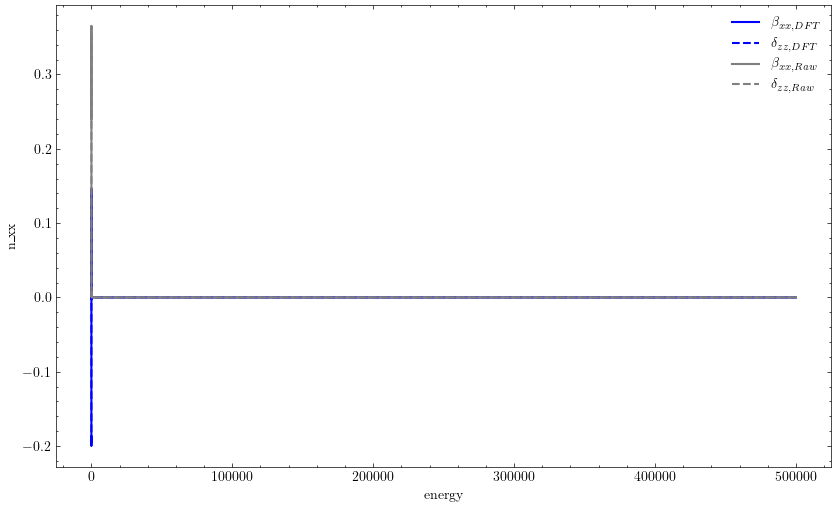

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=dft_optical_components,
    x="energy",
    y="n_xx",
    label=r"$\beta_{xx, DFT}$",
    color="blue",
    linewidth=1.5,
    ax=ax,
)
sns.lineplot(
    data=dft_optical_components,
    x="energy",
    y="n_zz",
    label=r"$\delta_{zz, DFT}$",
    color="blue",
    linewidth=1.5,
    linestyle="--",
    ax=ax,
)
sns.lineplot(
    data=raw_optical_components,
    x="energy",
    y="n_ixx",
    label=r"$\beta_{xx, Raw}$",
    color="grey",
    linewidth=1.5,
    ax=ax,
)
sns.lineplot(
    data=raw_optical_components,
    x="energy",
    y="n_izz",
    label=r"$\delta_{zz, Raw}$",
    color="grey",
    linewidth=1.5,
    linestyle="--",
    ax=ax,
)
sns.scatterplot(
    data=exp_optical_components,
    x="energy",
    y="n_ixx",
    label=r"$\beta_{xx, exp}$",
    color="k",
    s=10,
    edgecolor=None,
    linewidth=0.3,
    ax=ax,
)
sns.scatterplot(
    data=exp_optical_components,
    x="energy",
    y="n_xx",
    label=r"$\delta_{xx, exp}$",
    color="k",
    s=10,
    marker="s",
    edgecolor=None,
    linewidth=0.3,
    ax=ax,
)
sns.scatterplot(
    data=exp_optical_components,
    x="energy",
    y="n_izz",
    label=r"$\delta_{zz, exp}$",
    color="k",
    s=10,
    marker="^",
    edgecolor=None,
    linewidth=0.3,
    ax=ax,
)
sns.scatterplot(
    data=exp_optical_components,
    x="energy",
    y="n_izz",
    label=r"$\beta_{zz, exp}$",
    color="k",
    s=10,
    marker="v",
    edgecolor=None,
    linewidth=0.3,
    ax=ax,
)
ax.set_xlabel("Energy (eV)", fontsize=14, fontweight="bold")
ax.set_ylabel(r"Optical Constants $(\delta, \beta)$", fontsize=14, fontweight="bold")
ax.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))
ax.set_xlim(280, 295)
ax.set_ylim(-0.001, 0.003)

ValueError: Could not interpret value `energy` for `x`. An entry with this name does not appear in `data`.

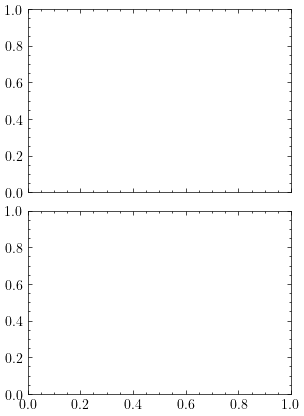

In [20]:
# --------------------------------------------------------------
#  Imports & style (unchanged from your original script)
# --------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

palette = {
    "refined": "blue",
    "raw": "gray",
}  # light gray

# --------------------------------------------------------------
#  Figure & axes (single‑column size)
# --------------------------------------------------------------
fig, (ax_beta, ax_delta) = plt.subplots(
    2,
    1,
    figsize=(3.4, 5.0),  # single‑column width
    sharex=True,
    # sharey="row",
    gridspec_kw=dict(hspace=0.1, wspace=0.1),
)

# --------------------------------------------------------------
#  Plot β (top panel) – suppress the per‑axis legend
# --------------------------------------------------------------

sns.scatterplot(
    data=exp_optical_components.iloc[::10],
    x="energy",
    y="n_ixx",
    label=r"$n_{\mathrm{xx,exp}}$",
    color="k",
    s=10,
    edgecolor="k",
    facecolor="none",
    linewidth=0.8,
    marker="o",
    ax=ax_beta,
    legend=False,
)

sns.lineplot(
    data=raw_optical_components,
    x="energy",
    y="n_ixx",
    label=r"$n_{\mathrm{xx,DFT}}$",
    color="red",
    linewidth=1.5,
    linestyle="--",
    ax=ax_beta,
    legend=False,
)
sns.lineplot(
    data=dft_optical_components,
    x="energy",
    y="n_ixx",
    label=r"$n_{\mathrm{xx,Refined}}$",
    color="red",
    linewidth=1.5,
    ax=ax_beta,
    legend=False,
)
sns.scatterplot(
    data=exp_optical_components.iloc[::10],
    x="energy",
    y="n_izz",
    label=r"$n_{\mathrm{zz,exp}}$",
    color=palette["refined"],
    s=10,
    edgecolor="k",
    facecolor="none",
    linewidth=0.8,
    marker="^",
    ax=ax_beta,
    legend=False,
)
sns.lineplot(
    data=raw_optical_components,
    x="energy",
    y="n_izz",
    label=r"$n_{\mathrm{zz,DFT}}$",
    color="blue",
    linewidth=1.5,
    linestyle="--",
    ax=ax_beta,
    legend=False,
)

sns.lineplot(
    data=dft_optical_components,
    x="energy",
    y="n_izz",
    label=r"$n_{\mathrm{zz,Refined}}$",
    color="blue",
    linewidth=1.5,
    linestyle="-",
    ax=ax_beta,
    legend=False,
)


ax_beta.set_ylabel(r"$\beta$ (a.u.)", fontsize=12, fontweight="bold")
ax_beta.set_ylim(0, 0.008)
ax_beta.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax_beta.tick_params(axis="both", which="major", labelsize=10)

# Add panel label (a)
ax_beta.text(
    0.02,
    0.95,
    "(a)",
    transform=ax_beta.transAxes,
    fontsize=12,
    fontweight="bold",
    verticalalignment="top",
    horizontalalignment="left",
)

# --------------------------------------------------------------
#  Plot δ (bottom panel) – also suppress the per‑axis legend
# --------------------------------------------------------------

sns.scatterplot(
    data=exp_optical_components.iloc[::10],
    x="energy",
    y="n_xx",
    label=r"$\delta_{\mathrm{xx,exp}}$",
    color="k",
    s=10,
    edgecolor="k",
    facecolor="none",
    linewidth=0.8,
    marker="o",
    ax=ax_delta,
    legend=False,
)
sns.lineplot(
    data=raw_optical_components,
    x="energy",
    y="n_xx",
    label=r"$\delta_{\mathrm{xx,RAW}}$",
    color="red",
    linewidth=1.5,
    linestyle="--",
    ax=ax_delta,
    legend=False,
)
sns.lineplot(
    data=dft_optical_components,
    x="energy",
    y="n_xx",
    label=r"$\delta_{\mathrm{xx,Refined}}$",
    color="red",
    linewidth=1.5,
    linestyle="-",
    ax=ax_delta,
    legend=False,
)
sns.scatterplot(
    data=exp_optical_components.iloc[::10],
    x="energy",
    y="n_zz",
    label=r"$\delta_{\mathrm{zz,exp}}$",
    color="k",
    s=10,
    edgecolor="k",
    facecolor="none",
    linewidth=0.8,
    marker="^",
    ax=ax_delta,
    legend=False,
)
sns.lineplot(
    data=raw_optical_components,
    x="energy",
    y="n_zz",
    label=r"$\delta_{\mathrm{zz,RAW}}$",
    color="blue",
    linewidth=1.5,
    linestyle="--",
    ax=ax_delta,
    legend=False,
)
sns.lineplot(
    data=dft_optical_components,
    x="energy",
    y="n_zz",
    label=r"$\delta_{\mathrm{zz,Refined}}$",
    color="blue",
    linewidth=1.5,
    linestyle="-",
    ax=ax_delta,
    legend=False,
)

ax_delta.set_xlabel("Energy (eV)", fontsize=12, fontweight="bold")
ax_delta.set_ylabel(r"$\delta$ (a.u.)", fontsize=12, fontweight="bold")
ax_delta.set_xlim(283, 295)
ax_delta.set_ylim(-0.004, 0.004)
# Set better x-axis ticks
ax_delta.set_xticks([283, 285, 287, 289, 291, 293, 295])
ax_delta.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax_delta.tick_params(axis="both", which="major", labelsize=10)

# Add panel label (b)
ax_delta.text(
    0.02,
    0.95,
    "(b)",
    transform=ax_delta.transAxes,
    fontsize=12,
    fontweight="bold",
    verticalalignment="top",
    horizontalalignment="left",
)


for ax in (ax_beta, ax_delta):
    ax.tick_params(direction="in")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.ticklabel_format(style="scientific", axis="y", scilimits=(0, 0))

# Grab handles & labels from both axes
handles_beta, labels_beta = ax_beta.get_legend_handles_labels()
handles_delta, labels_delta = ax_delta.get_legend_handles_labels()

# Concatenate while preserving order
all_handles = handles_beta + handles_delta
all_labels = labels_beta + labels_delta

# Remove duplicates (just in case the same label appears twice)
unique = {}
for h, l in zip(all_handles, all_labels):
    if l not in unique:
        unique[l] = h
final_handles = list(unique.values())
final_labels = list(unique.keys())

# -----------------------------------------------------------------
#  Option A – Legend **inside** the top panel (lower‑right corner)
# -----------------------------------------------------------------
ax_beta.legend(
    final_handles[:6],
    final_labels[:6],
    loc="upper right",
    handlelength=0.8,
    fontsize=9,
    frameon=False,
    ncol=2,
)

# --------------------------------------------------------------
#  Tight layout – leave room for the external legend
# --------------------------------------------------------------
# fig.tight_layout(rect=[0, 0, 0.85, 1])  # 0.85 leaves space for the legend on the right
plt.show()
# -----------------------------------------------------------------
fig.savefig(
    "Fig1_tensor.png", dpi=300, bbox_inches="tight"
)  # , bbox_extra_artists=(legend,)